In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [2]:
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

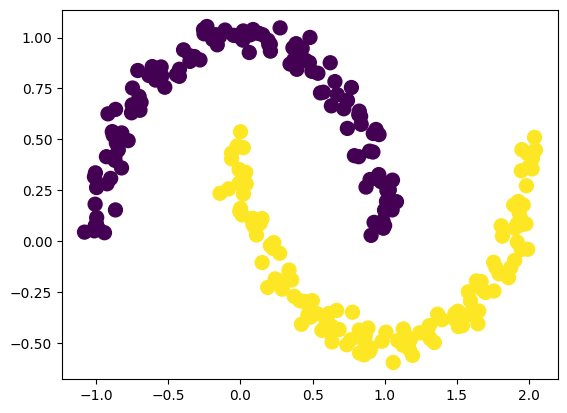

In [3]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [4]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [6]:
model.get_weights()[0]

array([[-0.47878852, -0.4051789 , -0.3021924 , -0.5516075 , -0.40887448,
        -0.24899885,  0.40072817, -0.6189976 ,  0.6102621 , -0.4239548 ],
       [ 0.47471398, -0.5712093 , -0.34599242,  0.7022895 , -0.68814117,
         0.5718383 , -0.15168399,  0.14307874,  0.6385754 , -0.13780552]],
      dtype=float32)

In [7]:
old_weights = model.get_weights()[0]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [9]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4900 - loss: 0.8312
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.8130 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7971 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7811 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.7682  
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7557 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7452 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7349 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7276 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7209 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7150 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - los

In [10]:
new_weights = model.get_weights()[0]

In [11]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [12]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [13]:
gradient

array([[  785.1932 ,   737.94995,   722.84894,   688.9721 ,   747.09735,
          849.6856 ,  -228.15918, -1074.5825 ,   759.3895 ,   800.86884],
       [-1096.668  ,  -877.86945,  -864.9684 ,  -913.78107,  -841.51166,
        -1116.1079 ,   383.69815,  1144.9758 ,  -647.0838 , -1022.63257]],
      dtype=float32)

In [14]:
percent_change

array([[163.99582 , 182.12943 , 239.20158 , 124.902596, 182.72047 ,
        341.2408  ,  56.936146, 173.60045 , 124.43663 , 188.9043  ],
       [231.01659 , 153.68613 , 249.99635 , 130.1146  , 122.28765 ,
        195.17894 , 252.95891 , 800.24176 , 101.33241 , 742.0839  ]],
      dtype=float32)

In [15]:
old_weights

array([[-0.47878852, -0.4051789 , -0.3021924 , -0.5516075 , -0.40887448,
        -0.24899885,  0.40072817, -0.6189976 ,  0.6102621 , -0.4239548 ],
       [ 0.47471398, -0.5712093 , -0.34599242,  0.7022895 , -0.68814117,
         0.5718383 , -0.15168399,  0.14307874,  0.6385754 , -0.13780552]],
      dtype=float32)

In [16]:
new_weights

array([[-1.2639817 , -1.1431289 , -1.0250413 , -1.2405796 , -1.1559719 ,
        -1.0986845 ,  0.62888736,  0.45558503, -0.14912748, -1.2248237 ],
       [ 1.5713819 ,  0.30666015,  0.518976  ,  1.6160706 ,  0.15337054,
         1.6879462 , -0.53538215, -1.0018971 ,  1.2856592 ,  0.88482714]],
      dtype=float32)

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
old_weights = model.get_weights()[0]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [21]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4600 - loss: 0.6932
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5900 - loss: 0.6928 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6924 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5100 - loss: 0.6917 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6910 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6898 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6849 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6785 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6698 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6581 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6416 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7550 - loss

In [22]:
new_weights = model.get_weights()[0]

In [23]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [24]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [25]:
gradient

array([[ -41.056416,  140.9532  ,  133.72026 ,  -58.845875,   70.97032 ,
           5.462974,  161.0217  ,  -20.397871,  -20.58494 , -111.62274 ],
       [ -11.971287, -124.40322 ,   74.904335, -163.63417 ,   30.677227,
         105.77428 ,  -88.00285 ,  106.991615,   30.33413 ,   81.665276]],
      dtype=float32)

In [26]:
percent_change

array([[188.89116  , 111.4306   ,  63.415997 ,  47.7595   ,  15.601689 ,
          6.894937 , 134.3552   ,   4.4617796,   8.055662 ,  22.899668 ],
       [  9.269634 , 623.7026   ,  42.855255 ,  25.314886 ,   5.944116 ,
         26.532448 ,  62.78742  ,  28.69874  ,  29.217525 ,  18.95823  ]],
      dtype=float32)

In [27]:
old_weights

array([[ 0.02173549, -0.12649417,  0.21086204,  0.12321293, -0.45488873,
         0.07923168, -0.11984777,  0.457169  , -0.2555338 ,  0.48744267],
       [-0.1291452 , -0.01994592,  0.17478448, -0.6463951 ,  0.516094  ,
        -0.39866012, -0.14016002, -0.37280944, -0.10382169,  0.43076426]],
      dtype=float32)

In [28]:
new_weights

array([[ 0.06279191, -0.26744738,  0.07714178,  0.18205881, -0.52585906,
         0.07376871, -0.28086948,  0.47756687, -0.23494887,  0.5990654 ],
       [-0.11717392,  0.1044573 ,  0.09988014, -0.4827609 ,  0.4854168 ,
        -0.5044344 , -0.05215717, -0.47980106, -0.13415582,  0.34909898]],
      dtype=float32)